In [25]:
import csv
import math
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms import community
from collections import defaultdict
 
# 1. LOAD DATA  +  DROP DUPLICATES
# ─────────────────────────────────────────────
FILE_PATH = "/Users/jolanababjak/Downloads/507 class/507 code/Health Data - Medicare & Networks /data/Medicare_FFS_CERT_2025.csv"
 
raw_rows = []
with open(FILE_PATH, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        raw_rows.append(row)

seen = set()
data = []
for row in raw_rows:
    key = frozenset(row.items())
    if key not in seen:
        seen.add(key)
        data.append(row)

print(f"Rows before dedup : {len(raw_rows)}")
print(f"Rows after  dedup : {len(data)}")
print(f"Duplicates removed: {len(raw_rows) - len(data)}")

Rows before dedup : 163940
Rows after  dedup : 95308
Duplicates removed: 68632


In [26]:
# Build provider,  error counts
provider_patterns = defaultdict(lambda: defaultdict(int))
provider_totals   = defaultdict(int)

for row in data:
    provider = row["Provider Type"]
    error    = row["Error Code"]

    if not error or error.strip() in ("-", ""):
        continue

    provider_patterns[provider][error] += 1
    provider_totals[provider]          += 1

# define providers list
providers = list(provider_patterns.keys())
N_providers = len(providers)

# Compute document frequency per error code
error_doc_freq = defaultdict(int)
for provider, errors in provider_patterns.items():
    for error in errors:
        error_doc_freq[error] += 1

# Build TF-IDF normalized provider profiles
provider_profiles = {}

for provider in providers:   #  provider is defined here
    total = provider_totals[provider]
    profile = {}
    for error, count in provider_patterns[provider].items():
        tf = count / total
        idf = math.log(N_providers / error_doc_freq[error])
        weight = tf * idf
        if weight > 0:
            profile[error] = weight
    provider_profiles[provider] = profile

In [27]:
def cosine_similarity(vec1: dict, vec2: dict) -> float:
    keys = set(vec1) | set(vec2)
    dot  = sum(vec1.get(k, 0) * vec2.get(k, 0) for k in keys)
    mag1 = math.sqrt(sum(v ** 2 for v in vec1.values()))
    mag2 = math.sqrt(sum(v ** 2 for v in vec2.values()))
    if mag1 == 0 or mag2 == 0:
        return 0.0
    return dot / (mag1 * mag2)
 

In [28]:
# 4. BUILD GRAPH
#    Raise threshold to cut clutter; keep only

#    the top-K edges per node to keep it clean.
# ─────────────────────────────────────────────
SIMILARITY_THRESHOLD = 0.75   # raise to reduce noise (try 0.8 if still messy)
TOP_K_EDGES          = 5      # each node keeps at most K strongest neighbours
 
G = nx.Graph()
 
# Add nodes with total-denial count as attribute
for p in providers:
    G.add_node(p, total_denials=provider_totals[p])
 
# Compute all pairwise similarities above threshold
candidate_edges = []
for i in range(len(providers)):
    for j in range(i + 1, len(providers)):
        p1, p2 = providers[i], providers[j]
        sim = cosine_similarity(provider_profiles[p1], provider_profiles[p2])
        if sim >= SIMILARITY_THRESHOLD:
            candidate_edges.append((p1, p2, sim))
 
# Per-node top-K filtering  →  avoids "hairball" effect
from collections import defaultdict as dd
node_edge_count = dd(int)
for p1, p2, sim in sorted(candidate_edges, key=lambda x: -x[2]):
    if node_edge_count[p1] < TOP_K_EDGES and node_edge_count[p2] < TOP_K_EDGES:
        G.add_edge(p1, p2, weight=sim)
        node_edge_count[p1] += 1
        node_edge_count[p2] += 1

print(f"\nGraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph: 108 nodes, 254 edges


In [29]:
# 5. COMMUNITY DETECTION
# ─────────────────────────────────────────────
# Work only on the largest connected component for clarity
components = sorted(nx.connected_components(G), key=len, reverse=True)
G_main     = G.subgraph(components[0]).copy()
 
communities_list = list(community.greedy_modularity_communities(G_main))
communities_list.sort(key=len, reverse=True)   # largest cluster first
 
# Assign community id to each node
node_community = {}
for idx, comm in enumerate(communities_list):
    for node in comm:
        node_community[node] = idx
 
print(f"\nCommunities found in main component: {len(communities_list)}")
for i, comm in enumerate(communities_list):
    print(f"  Cluster {i+1} ({len(comm)} providers): {sorted(comm)[:5]} ...")
 


Communities found in main component: 9
  Cluster 1 (23 providers): ['Ambulance Service Supplier (e.g., private ambulance companies, funeral homes)', 'General Practice', 'HHA', 'Home Health Agency', 'Hospice'] ...
  Cluster 2 (12 providers): ['Cardiology', 'FQHC', 'General Surgery', 'Geriatric Medicine', 'Internal Medicine'] ...
  Cluster 3 (10 providers): ['Cardiac Surgery', 'Comprehensive Outpatient Rehab Facility (CORF)', 'DRG Short Term', 'Endocrinology', 'Hematology'] ...
  Cluster 4 (10 providers): ['Advanced Heart Failure & Transplant Cardiology', 'Clinical Nurse Specialist', 'DRG Long Term', 'Emergency Medicine', 'Gynecological/Oncology'] ...
  Cluster 5 (10 providers): ['Anesthesiology', 'Clinical Cardiatric Electrophysiology', 'Clinical Social Worker', 'Colorectal Surgery (formerly proctology)', 'Dermatology'] ...
  Cluster 6 (9 providers): ['Audiologist (Billing Independently)', 'Chiropractic', 'Clinical Psychologist', 'Interventional Cardiology', 'OPPS, Laboratory (an FI), 


Saved → /Users/jolanababjak/Downloads/507 class/507 code/Health Data - Medicare & Networks /medicare_denial_network.png


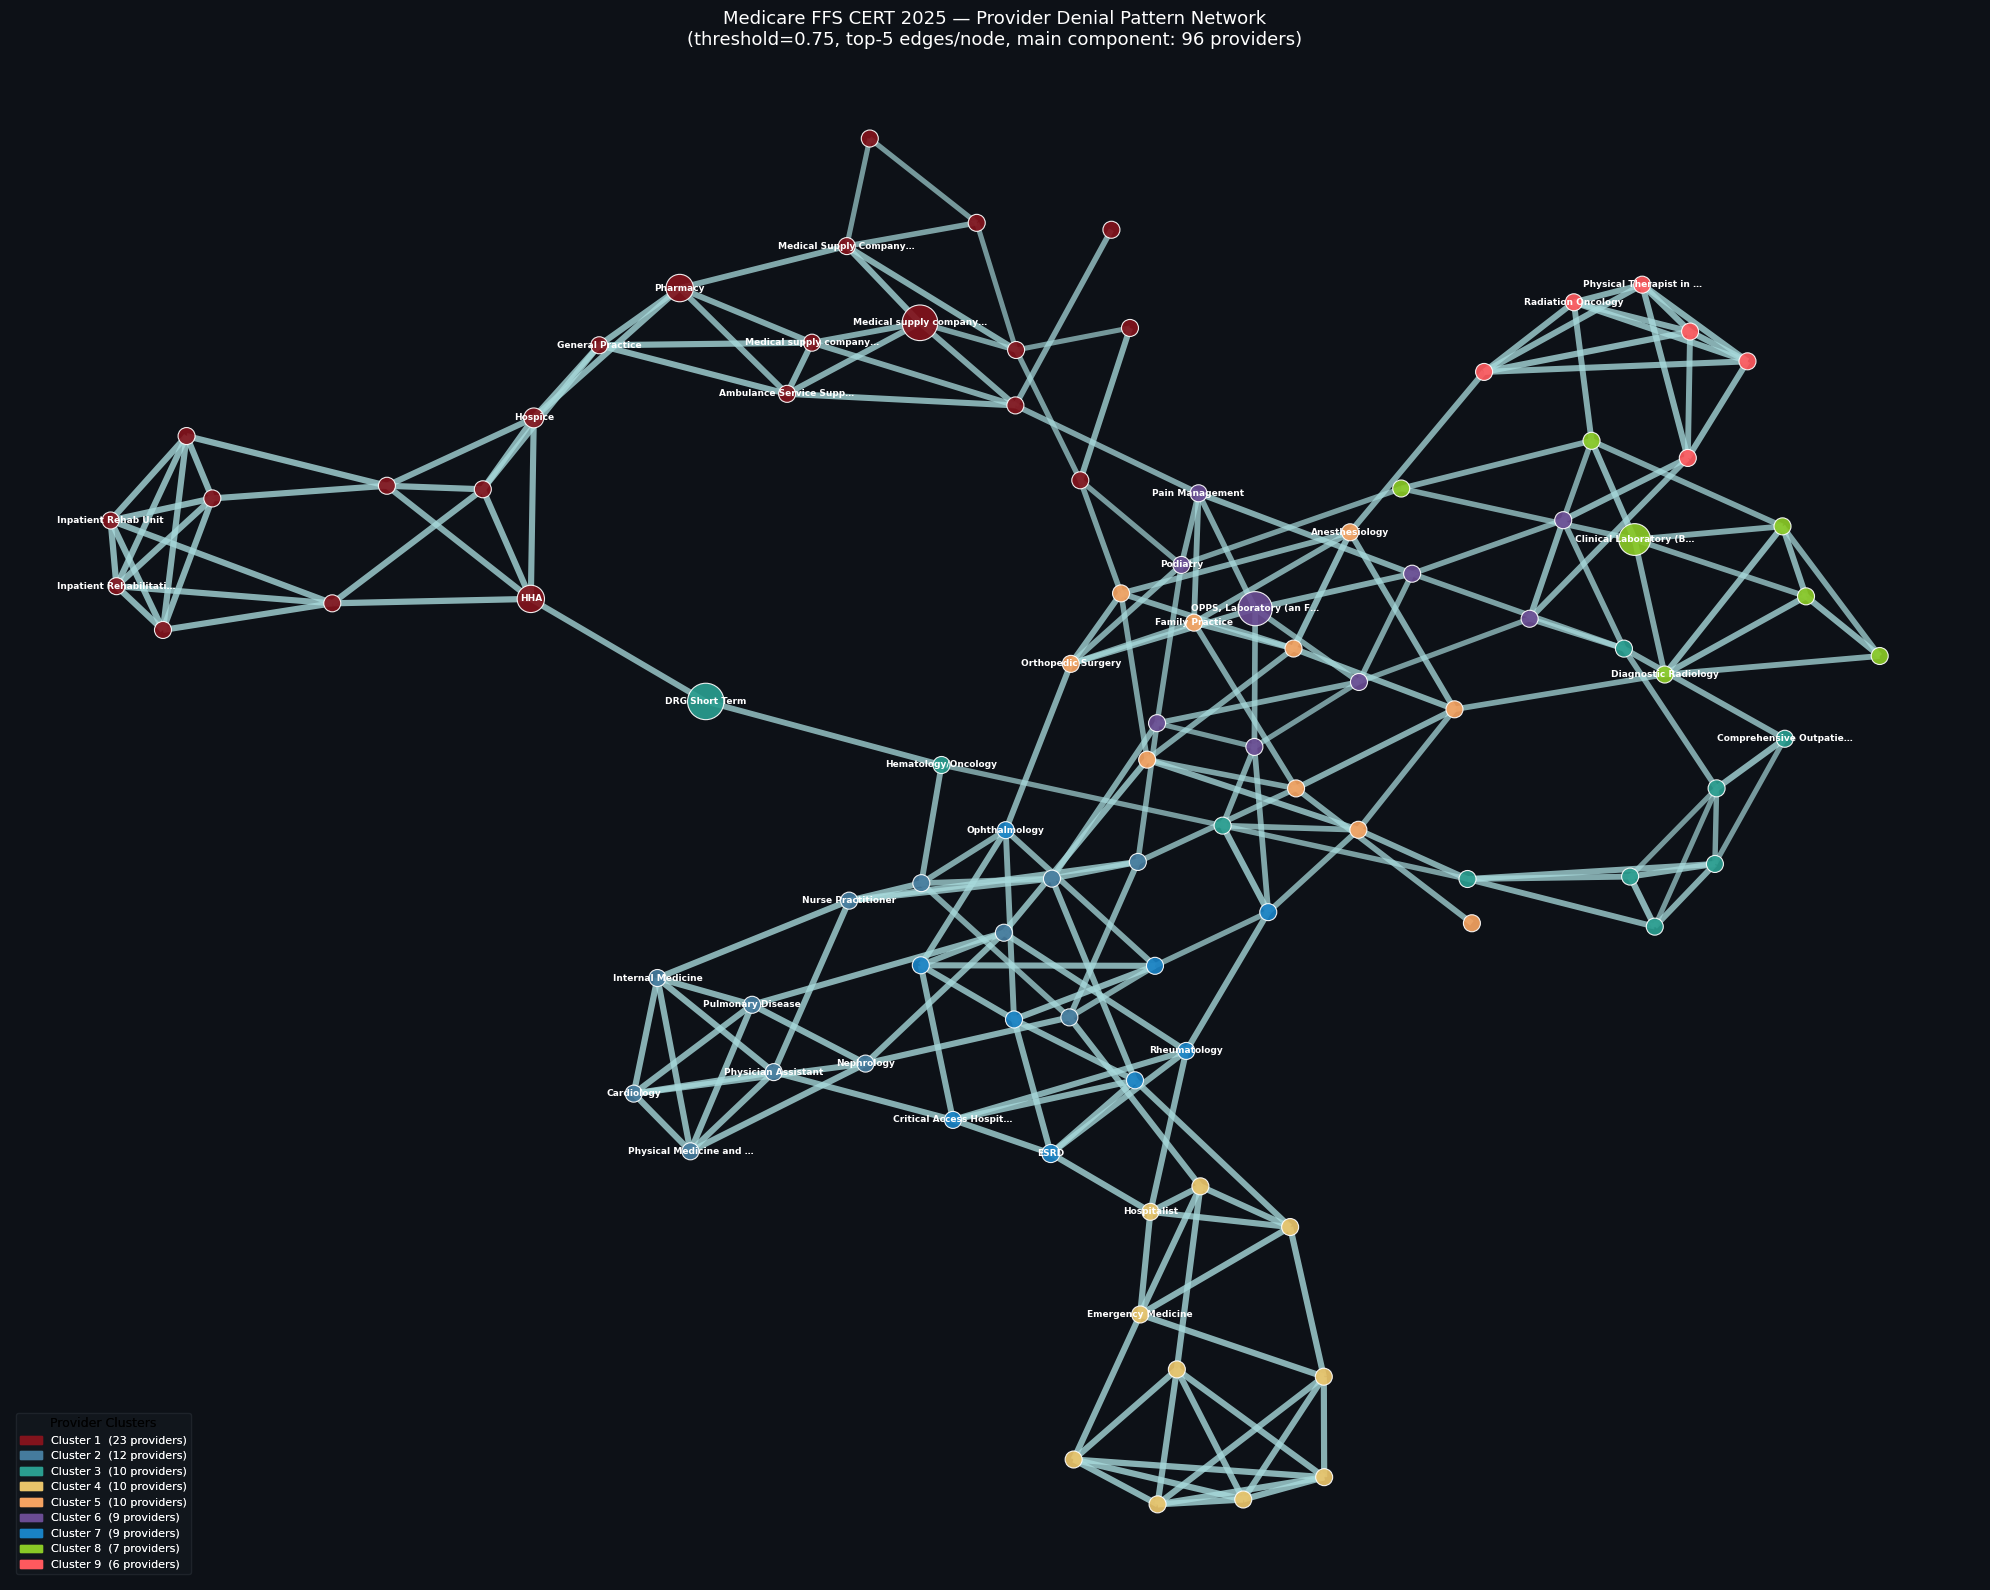

In [30]:
# 6. VISUALISE
# ─────────────────────────────────────────────
# Palette — distinct, colour-blind friendly-ish
PALETTE = [
    "#82131C", "#457B9D", "#2A9D8F", "#E9C46A",
    "#F4A261", "#6A4C93", "#1982C4", "#8AC926",
    "#FF595E", "#FFCA3A",
]
 
fig, ax = plt.subplots(figsize=(20, 16))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")
 
# Layout: kamada_kawai respects edge weights → natural clusters
pos = nx.kamada_kawai_layout(G_main, weight="weight")
 
# Node attributes
node_list   = list(G_main.nodes())
node_colors = [PALETTE[node_community.get(n, 0) % len(PALETTE)] for n in node_list]
node_sizes  = [
    max(150, min(1800, G_main.nodes[n]["total_denials"] * 0.4))
    for n in node_list
]
 
# Edge attributes
edges       = list(G_main.edges(data=True))
edge_weights= [d["weight"] for _, _, d in edges]
max_w       = max(edge_weights) if edge_weights else 1
edge_widths = [1.0 + 3.5 * (w / max_w) for w in edge_weights]
edge_alphas = [0.25 + 0.55 * (w / max_w) for w in edge_weights]
 
# Draw edges (batch by alpha band for performance)
for (u, v, d), lw, alpha in zip(edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(
        G_main, pos,
        edgelist=[(u, v)],
        width=lw,
        alpha=alpha,
        edge_color="#A8DADC",
        ax=ax,
    )
 
# Draw nodes
nx.draw_networkx_nodes(
    G_main, pos,
    nodelist=node_list,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.92,
    linewidths=0.8,
    edgecolors="#FFFFFF",
    ax=ax,
)
 
# Labels — only show high-volume providers to avoid overlap
LABEL_MIN_DENIALS = 50   # tweak to show more/fewer labels
label_dict = {
    n: (n[:22] + "…" if len(n) > 22 else n)   # truncate long names
    for n in node_list
    if G_main.nodes[n]["total_denials"] >= LABEL_MIN_DENIALS
}
 
nx.draw_networkx_labels(
    G_main, pos,
    labels=label_dict,
    font_size=6.5,
    font_color="#FFFFFF",
    font_weight="bold",
    ax=ax,
)
 
# ── Legend: communities ──────────────────────
legend_patches = []
for i, comm in enumerate(communities_list):
    color  = PALETTE[i % len(PALETTE)]
    label  = f"Cluster {i+1}  ({len(comm)} providers)"
    legend_patches.append(mpatches.Patch(color=color, label=label))
 
legend = ax.legend(
    handles=legend_patches,
    loc="lower left",
    framealpha=0.3,
    facecolor="#161B22",
    edgecolor="#30363D",
    labelcolor="white",
    fontsize=8,
    title="Provider Clusters",
    title_fontsize=9,
)
legend.get_title().set_color("white")
 
# ── Node-size legend ─────────────────────────
for denial_count, label in [(50, "50 denials"), (200, "200"), (500, "500+")]:
    ax.scatter([], [], s=max(150, denial_count * 0.4),
               c="#888", alpha=0.7, label=label)
ax.legend(
    *[*zip(*[(mpatches.Patch(color="#888", alpha=0), f"{v} denials")
             for v in [50, 200, 500]])],
    loc="lower right", framealpha=0.3, facecolor="#161B22",
    edgecolor="#30363D", labelcolor="white", fontsize=7.5,
    title="Node size = denial volume", title_fontsize=8,
).get_title().set_color("white")
 
# Re-add community legend (second legend call replaces the first)
ax.add_artist(ax.legend(
    handles=legend_patches,
    loc="lower left",
    framealpha=0.3,
    facecolor="#161B22",
    edgecolor="#30363D",
    labelcolor="white",
    fontsize=8,
    title="Provider Clusters",
    title_fontsize=9,
))
 
ax.set_title(
    "Medicare FFS CERT 2025 — Provider Denial Pattern Network\n"
    f"(threshold={SIMILARITY_THRESHOLD}, top-{TOP_K_EDGES} edges/node, "
    f"main component: {G_main.number_of_nodes()} providers)",
    color="white", fontsize=13, pad=14,
)
ax.axis("off")
plt.tight_layout()
 
out_path = "/Users/jolanababjak/Downloads/507 class/507 code/Health Data - Medicare & Networks /medicare_denial_network.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"\nSaved → {out_path}")
plt.show()